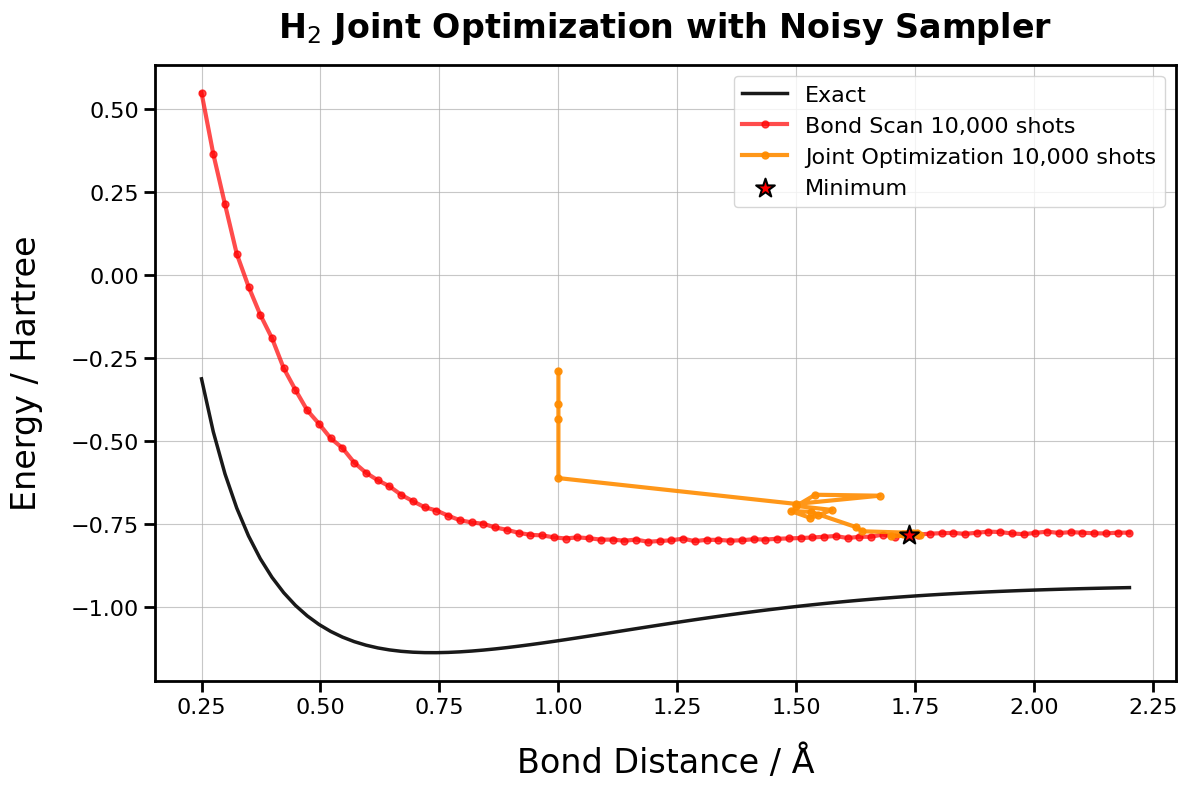

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load exact reference data
exact_file = '../data/h2_bond_scan_exact.json'
joint_opt_file = '../data/h2_joint_optimization_noisy.json'
bond_scan_file = '../data/h2_bond_scan_10000shots.json'

# Create the plot
plt.figure(figsize=(12, 8))

# Plot exact reference data
with open(exact_file, 'r') as f:
    exact_data = json.load(f)
exact_distances = exact_data['distances']
exact_energies = exact_data['energies']
plt.plot(exact_distances, exact_energies, 'k-', linewidth=2.5, label='Exact', alpha=0.9, zorder=1)

# Plot bond scan with 10000 shots
with open(bond_scan_file, 'r') as f:
    bond_scan_data = json.load(f)
bond_scan_distances = bond_scan_data['distances']
bond_scan_energies = bond_scan_data['energies']
plt.plot(bond_scan_distances, bond_scan_energies, 'o-', color='red', linewidth=3, 
         markersize=5, alpha=0.7, label='Bond Scan 10,000 shots', zorder=2)

# Plot joint optimization trajectory
with open(joint_opt_file, 'r') as f:
    joint_data = json.load(f)
joint_distances = joint_data['history_distances']
joint_energies = joint_data['history_raw_energies']
optimal_distance = joint_data['optimal_distance']
optimal_energy = joint_data['optimal_energy']

# Plot optimization path
plt.plot(joint_distances, joint_energies, 'o-', color='darkorange', linewidth=3, 
         markersize=5, alpha=0.9, label='Joint Optimization 10,000 shots', zorder=3)

# Highlight the optimal point
plt.scatter([optimal_distance], [optimal_energy], s=200, color='red', 
            marker='*', edgecolors='black', linewidths=1.5, 
            label=f'Minimum', zorder=4)



plt.xlabel('Bond Distance / Å', fontsize=24, labelpad=20)
plt.ylabel('Energy / Hartree', fontsize=24, labelpad=20)

ax = plt.gca()
ax.set_axisbelow(True)  # Put grid behind plot elements
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(axis='both', which='major', labelsize=16, length=8, width=2)

plt.title('H$_2$ Joint Optimization with Noisy Sampler', fontsize=24, fontweight='bold', pad=20)
plt.legend(fontsize=16, loc='best')
plt.grid(True, alpha=0.7)
plt.tight_layout()


# plt.savefig('../images/presentation/noisy_joint_optimization.png', dpi=300, bbox_inches='tight')
plt.show()